In [0]:
population_df = spark.read.load("dbfs:/FileStore/world_population.csv",
    format = "csv",
    inferSchema = "true",
    header = "true" )

population_df.display()

Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.0
203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.01,0.0
42,AGO,Angola,Luanda,Africa,35588987,33428485,28127721,23364185,16394062,11828638,8330047,6029700,1246700,28.5466,1.0315,0.45
224,AIA,Anguilla,The Valley,North America,15857,15585,14525,13172,11047,8316,6560,6283,91,174.2527,1.0066,0.0
201,ATG,Antigua and Barbuda,Saint John’s,North America,93763,92664,89941,85695,75055,63328,64888,64516,442,212.1335,1.0058,0.0
33,ARG,Argentina,Buenos Aires,South America,45510318,45036032,43257065,41100123,37070774,32637657,28024803,23842803,2780400,16.3683,1.0052,0.57
140,ARM,Armenia,Yerevan,Asia,2780469,2805608,2878595,2946293,3168523,3556539,3135123,2534377,29743,93.4831,0.9962,0.03


In [0]:
from pyspark.sql.functions import *

###Exploratory Data Analysis

In [0]:
display(population_df.select([count(when(col(c).isNull(), c)).alias(c) for c in population_df.columns]))

Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


No missing values!

In [0]:
population_df.describe().display()

summary,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
count,234,234,234,234,234,234,234,234,234,234,234,234,234,234,234,234,234
mean,117.5,null,null,null,null,3.407441470940171E7,3.3501070952991452E7,3.1729956243589744E7,2.9845235034188036E7,2.6269468816239316E7,2.2710220790598292E7,1.8984616970085472E7,1.5786908807692308E7,581449.3846153846,452.12704358974344,1.0095773504273502,0.4270512820512822
stddev,67.6941651843052,null,null,null,null,1.3676642480476278E8,1.3558987692443877E8,1.3040499275175995E8,1.2421848763299787E8,1.1169820671907006E8,9.783217334675097E7,8.178518608420148E7,6.779509164323564E7,1761840.8640631405,2066.1219036046114,0.01338498453399879,1.7149767768102138
min,1,ABW,Afghanistan,Abu Dhabi,Africa,510,520,564,596,651,700,733,752,1,0.0261,0.912,0.0
max,234,ZWE,Zimbabwe,Zagreb,South America,1425887337,1424929781,1393715448,1348191368,1264099069,1153704252,982372466,822534450,17098242,23172.2667,1.0691,17.88


In [0]:
population_df.printSchema()

root
 |-- Rank: integer (nullable = true)
 |-- CCA3: string (nullable = true)
 |-- Country/Territory: string (nullable = true)
 |-- Capital: string (nullable = true)
 |-- Continent: string (nullable = true)
 |-- 2022 Population: integer (nullable = true)
 |-- 2020 Population: integer (nullable = true)
 |-- 2015 Population: integer (nullable = true)
 |-- 2010 Population: integer (nullable = true)
 |-- 2000 Population: integer (nullable = true)
 |-- 1990 Population: integer (nullable = true)
 |-- 1980 Population: integer (nullable = true)
 |-- 1970 Population: integer (nullable = true)
 |-- Area (km²): integer (nullable = true)
 |-- Density (per km²): double (nullable = true)
 |-- Growth Rate: double (nullable = true)
 |-- World Population Percentage: double (nullable = true)



In [0]:
# Renaming the columns
population_df = population_df.withColumnRenamed("Country/Territory", "country") \
       .withColumnRenamed("2022 Population", "2022_pop") \
       .withColumnRenamed("2020 Population", "2020_pop") \
       .withColumnRenamed("2015 Population", "2015_pop") \
       .withColumnRenamed("2010 Population", "2010_pop") \
       .withColumnRenamed("2000 Population", "2000_pop") \
       .withColumnRenamed("1990 Population", "1990_pop") \
       .withColumnRenamed("1980 Population", "1980_pop") \
       .withColumnRenamed("1970 Population", "1970_pop") \
       .withColumnRenamed("Area (km²)", "area") \
       .withColumnRenamed("Density (per km²)", "density") \
       .withColumnRenamed("Growth Rate", "growth_rate")

In [0]:
population_df.columns

Out[7]: ['Rank',
 'CCA3',
 'country',
 'Capital',
 'Continent',
 '2022_pop',
 '2020_pop',
 '2015_pop',
 '2010_pop',
 '2000_pop',
 '1990_pop',
 '1980_pop',
 '1970_pop',
 'area',
 'density',
 'growth_rate',
 'World Population Percentage']

In [0]:
population_df.display()

Rank,CCA3,country,Capital,Continent,2022_pop,2020_pop,2015_pop,2010_pop,2000_pop,1990_pop,1980_pop,1970_pop,area,density,growth_rate,World Population Percentage
36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.0
203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.01,0.0
42,AGO,Angola,Luanda,Africa,35588987,33428485,28127721,23364185,16394062,11828638,8330047,6029700,1246700,28.5466,1.0315,0.45
224,AIA,Anguilla,The Valley,North America,15857,15585,14525,13172,11047,8316,6560,6283,91,174.2527,1.0066,0.0
201,ATG,Antigua and Barbuda,Saint John’s,North America,93763,92664,89941,85695,75055,63328,64888,64516,442,212.1335,1.0058,0.0
33,ARG,Argentina,Buenos Aires,South America,45510318,45036032,43257065,41100123,37070774,32637657,28024803,23842803,2780400,16.3683,1.0052,0.57
140,ARM,Armenia,Yerevan,Asia,2780469,2805608,2878595,2946293,3168523,3556539,3135123,2534377,29743,93.4831,0.9962,0.03


In [0]:
# Create a temporary view from the DataFrame
population_df.createOrReplaceTempView("population_view")

###Data Insights (SparkSQL)

#### 1) How has the population growth in Portugal been in the last 50 years?

In [0]:
# Query the temporary view for India's population data
portugal_population = spark.sql("""
                             SELECT 2022_pop, 2020_pop, 2015_pop, 2010_pop, 2000_pop, 1990_pop, 1980_pop, 1970_pop
                             FROM population_view
                             WHERE country = 'Portugal'
                             """)

# Show the result
portugal_population.display()

2022_pop,2020_pop,2015_pop,2010_pop,2000_pop,1990_pop,1980_pop,1970_pop
10270865,10298192,10365435,10588401,10300626,10007346,9785252,8683631


Databricks visualization. Run in Databricks to view.

Portugal had a big populational increase from 1970 to 2000 but then stagnated until 2022 decreasing slightly.

#### 2) What is the continent with the largest population? (last known data in 2022)

In [0]:
# Query the temporary view to get the population for each country in 2022
population_by_country = spark.sql("""
                                 SELECT CCA3, 2022_pop
                                 FROM population_view
                                 ORDER BY 2022_pop DESC
                                 """)
population_by_country.display()

CCA3,2022_pop
CHN,1425887337
IND,1417173173
USA,338289857
IDN,275501339
PAK,235824862
NGA,218541212
BRA,215313498
BGD,171186372
RUS,144713314
MEX,127504125


Databricks visualization. Run in Databricks to view.

In [0]:
continents_pop = spark.sql('''
                           SELECT Continent, SUM(2022_pop) AS total_population_2022
                           FROM population_view
                           GROUP BY Continent
                           ORDER BY total_population_2022 DESC
                           ''')
continents_pop.display()

Continent,total_population_2022
Asia,4721383274
Africa,1426730932
Europe,743147538
North America,600296136
South America,436816608
Oceania,45038554


Asia is definitely the continent with more population, having the two countries with largest population (China and India).

#### 3) What continent have the highest populational density?

In [0]:
continents_density = spark.sql('''
                           SELECT country, CCA3, density
                           FROM population_view
                           ORDER BY density DESC
                           ''')
continents_density.display()

country,CCA3,density
Macau,MAC,23172.2667
Monaco,MCO,18234.5
Singapore,SGP,8416.4634
Hong Kong,HKG,6783.3922
Gibraltar,GIB,5441.5
Bahrain,BHR,1924.4876
Maldives,MDV,1745.9567
Malta,MLT,1687.6139
Sint Maarten,SXM,1299.2647
Bermuda,BMU,1188.5926


Databricks visualization. Run in Databricks to view.

In [0]:
continents_density = spark.sql('''
                               SELECT continent, SUM(2022_pop) AS total_population,
                                                 SUM(area) AS total_area,
                                                 SUM(2022_pop) / SUM(area) AS population_density
                               FROM population_view
                               GROUP BY continent
                               ORDER BY population_density DESC
                               ''')
continents_density.display()

continent,total_population,total_area,population_density
Asia,4721383274,32138141,146.90903478206783
Africa,1426730932,30317963,47.05893110299
Europe,743147538,23010411,32.296143602128616
North America,600296136,24244178,24.760424378999364
South America,436816608,17833382,24.494322389325816
Oceania,45038554,8515081,5.2892690040176955


The continent with the highest populational density is Asia including the territory with the highest populational density Macau.

#### 4) How have the countries with the largest populations currently have grown in the last 50 years?

In [0]:
# Get the top 10 countries by population in 2022
top10_countries_2022 = spark.sql("""
    SELECT country, 2022_pop
    FROM population_view
    ORDER BY 2022_pop DESC
    LIMIT 10
""")
top10_countries_2022.createOrReplaceTempView("top10_countries_2022")
top10_countries_2022.show()


+-------------+----------+
|      country|  2022_pop|
+-------------+----------+
|        China|1425887337|
|        India|1417173173|
|United States| 338289857|
|    Indonesia| 275501339|
|     Pakistan| 235824862|
|      Nigeria| 218541212|
|       Brazil| 215313498|
|   Bangladesh| 171186372|
|       Russia| 144713314|
|       Mexico| 127504125|
+-------------+----------+



In [0]:
# Calculate the growth metrics for each of the top 10 countries
population_growth = spark.sql("""
                              SELECT p.country,
                                     p.1970_pop AS population_1970,
                                     p.1980_pop AS population_1980,
                                     p.1990_pop AS population_1990,
                                     p.2000_pop AS population_2000,
                                     p.2010_pop AS population_2010,
                                     p.2015_pop AS population_2015,
                                     p.2020_pop AS population_2020,
                                     p.2022_pop AS population_2022,
                                     (p.2022_pop - p.1970_pop) AS absolute_growth
                              FROM population_view p
                              INNER JOIN top10_countries_2022 t5 ON p.country = t5.country
                              ORDER BY population_2022 DESC
                              """)
population_growth.display()

country,population_1970,population_1980,population_1990,population_2000,population_2010,population_2015,population_2020,population_2022,absolute_growth
China,822534450,982372466,1153704252,1264099069,1348191368,1393715448,1424929781,1425887337,603352887
India,557501301,696828385,870452165,1059633675,1240613620,1322866505,1396387127,1417173173,859671872
United States,200328340,223140018,248083732,282398554,311182845,324607776,335942003,338289857,137961517
Indonesia,115228394,148177096,182159874,214072421,244016173,259091970,271857970,275501339,160272945
Pakistan,59290872,80624057,115414069,154369924,194454498,210969298,227196741,235824862,176533990
Nigeria,55569264,72951439,95214257,122851984,160952853,183995785,208327405,218541212,162971948
Brazil,96369875,122288383,150706446,175873720,196353492,205188205,213196304,215313498,118943623
Bangladesh,67541860,83929765,107147651,129193327,148391139,157830000,167420951,171186372,103644512
Russia,130093010,138257420,148005704,146844839,143242599,144668389,145617329,144713314,14620304
Mexico,50289306,67705186,81720428,97873442,112532401,120149897,125998302,127504125,77214819


Databricks visualization. Run in Databricks to view.

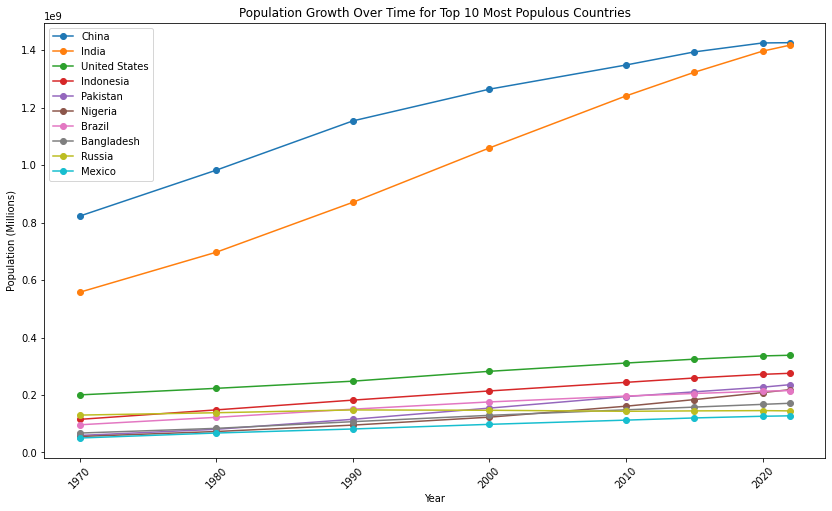

In [0]:
#import require libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# List of columns representing years
years = ["population_1970", "population_1980", "population_1990", "population_2000", "population_2010", "population_2015", "population_2020", "population_2022"]
population_growth = population_growth.toPandas()
plt.figure(figsize=(14, 8))

for index, row in population_growth.iterrows():
    populations = row[years].values
    plt.plot(
        [1970, 1980, 1990, 2000, 2010, 2015, 2020, 2022],
        populations,
        marker='o',
        label=row['country']
    )

plt.xticks(rotation=45)
plt.title("Population Growth Over Time for Top 10 Most Populous Countries")
plt.xlabel("Year")
plt.ylabel("Population (Millions)")
plt.legend()
plt.show()


We can clearly see that even though China and India are the countries with the largest population, they are also the ones with the highest growth in the last 50 years, being India the one with the highest growth.

#### 5) How have the countries/territories with the lowest populations currently have grown in the last 50 years?

In [0]:
# Get the lowest 10 populations in 2022
low10_2022 = spark.sql("""
    SELECT country, 2022_pop
    FROM population_view
    ORDER BY 2022_pop ASC
    LIMIT 10
""")
low10_2022.createOrReplaceTempView("low10_2022")
low10_2022.show()

+--------------------+--------+
|             country|2022_pop|
+--------------------+--------+
|        Vatican City|     510|
|             Tokelau|    1871|
|                Niue|    1934|
|    Falkland Islands|    3780|
|          Montserrat|    4390|
|Saint Pierre and ...|    5862|
|    Saint Barthelemy|   10967|
|              Tuvalu|   11312|
|   Wallis and Futuna|   11572|
|               Nauru|   12668|
+--------------------+--------+



In [0]:
population_growth_low = spark.sql("""
                              SELECT p.country,
                                     p.1970_pop AS population_1970,
                                     p.1980_pop AS population_1980,
                                     p.1990_pop AS population_1990,
                                     p.2000_pop AS population_2000,
                                     p.2010_pop AS population_2010,
                                     p.2015_pop AS population_2015,
                                     p.2020_pop AS population_2020,
                                     p.2022_pop AS population_2022,
                                     (p.2022_pop - p.1970_pop) AS absolute_growth
                              FROM population_view p
                              INNER JOIN low10_2022 t5 ON p.country = t5.country
                              ORDER BY population_2022 DESC
                              """)
population_growth_low.display()

country,population_1970,population_1980,population_1990,population_2000,population_2010,population_2015,population_2020,population_2022,absolute_growth
Nauru,6663,7635,9598,10377,10241,11185,12315,12668,6005
Wallis and Futuna,9377,11315,13454,14723,13142,12182,11655,11572,2195
Tuvalu,5814,7731,9182,9638,10550,10877,11069,11312,5498
Saint Barthelemy,2417,2983,5168,7082,8988,9643,10681,10967,8550
Saint Pierre and Miquelon,5537,6106,6324,6274,6052,5978,5906,5862,325
Montserrat,11402,11452,10805,5138,4938,5059,4500,4390,-7012
Falkland Islands,2274,2240,2332,3080,3187,3408,3747,3780,1506
Niue,5185,3637,2533,2074,1812,1847,1942,1934,-3251
Tokelau,1714,1647,1669,1666,1367,1454,1827,1871,157
Vatican City,752,733,700,651,596,564,520,510,-242


Databricks visualization. Run in Databricks to view.

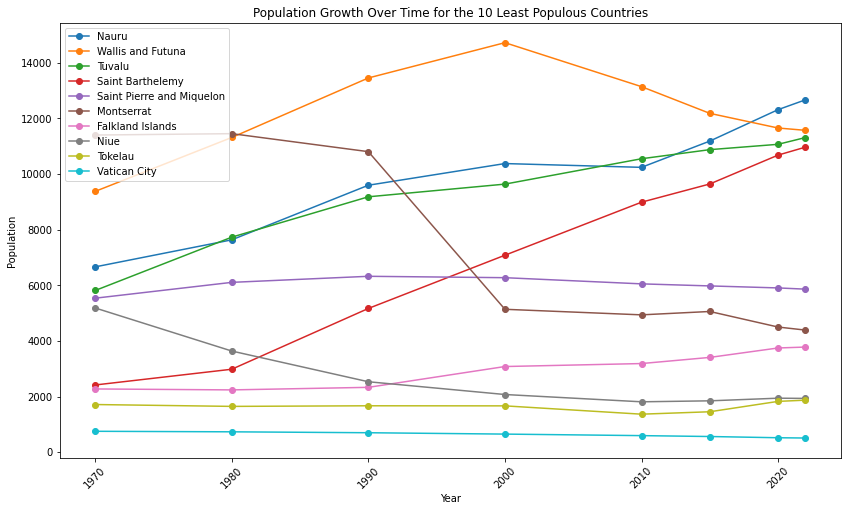

In [0]:
population_growth_low = population_growth_low.toPandas()
plt.figure(figsize=(14, 8))

for index, row in population_growth_low.iterrows():
    populations = row[years].values
    plt.plot(
        [1970, 1980, 1990, 2000, 2010, 2015, 2020, 2022],
        populations,
        marker='o',
        label=row['country']
    )

plt.xticks(rotation=45)
plt.title("Population Growth Over Time for the 10 Least Populous Countries/Territories")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.show()

We can have some interesting conclusions while analysing the growth in the last 50 years of the 10 smallest populations in the world. From this group, Saint Barthelemy is the one with biggest growth, and we can also say that Montserrat is the one with biggest populational decrease. Beside that, Vatican City is still the smallest country not having big changes in its population.

#### 6) Which continent has the highest population growth in the last 50 years?

In [0]:
continent_growth = spark.sql("""
                                 SELECT continent,
                                        SUM(1970_pop) AS population_1970,
                                        SUM(1980_pop) AS population_1980,
                                        SUM(1990_pop) AS population_1990,
                                        SUM(2000_pop) AS population_2000,
                                        SUM(2010_pop) AS population_2010,
                                        SUM(2015_pop) AS population_2015,
                                        SUM(2020_pop) AS population_2020,
                                        SUM(2022_pop) AS population_2022,
                                        (population_2022 - population_1970) AS absolute_growth
                                 FROM population_view
                                 GROUP BY continent
                                 ORDER BY absolute_growth DESC
                                 """)

continent_growth.display()


continent,population_1970,population_1980,population_1990,population_2000,population_2010,population_2015,population_2020,population_2022,absolute_growth
Asia,2144906290,2635334228,3210563577,3735089604,4220041327,4458250182,4663086535,4721383274,2576476984
Africa,365444348,481536377,638150629,818946032,1055228072,1201102442,1360671810,1426730932,1061286584
North America,315434606,368293361,421266425,486069584,542720651,570383850,594236593,600296136,284861530
South America,192947156,241789006,297146415,349634282,393078250,413134396,431530043,436816608,243869452
Europe,655923991,692527159,720320797,726093423,735613934,741535608,745792196,743147538,87223547
Oceania,19480270,22920240,26743822,31222778,37102764,40403283,43933426,45038554,25558284


Databricks visualization. Run in Databricks to view.

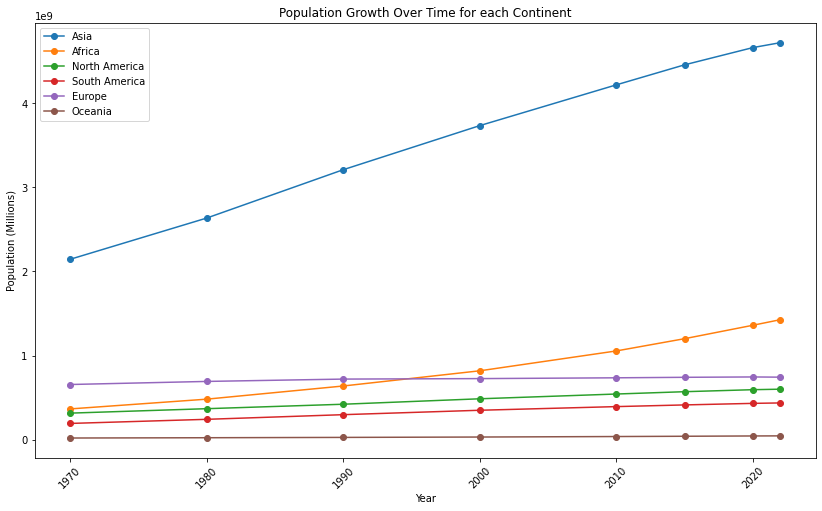

In [0]:
continent_growth = continent_growth.toPandas()
plt.figure(figsize=(14, 8))

for index, row in continent_growth.iterrows():
    populations = row[years].values
    plt.plot(
        [1970, 1980, 1990, 2000, 2010, 2015, 2020, 2022],
        populations,
        marker='o',
        label=row['continent']
    )

plt.xticks(rotation=45)
plt.title("Population Growth Over Time for each Continent")
plt.xlabel("Year")
plt.ylabel("Population (Millions)")
plt.legend()
plt.show()

As expected Asia is the continent with the biggest growth over the last 50 years. Beside that, we can see an interesting insight, we can see that the African population has exceeded the European between 1990 and 2000, being the second continent with the biggest growth.

#### 7) What is the relation between the country area and its population in Asia?

In [0]:
area_density_asia = spark.sql('''
                         SELECT country, 2022_pop, area, density
                         FROM population_view
                         WHERE continent = 'Asia'
                         ORDER BY 2022_pop DESC
                         ''')
area_density_asia.display()

country,2022_pop,area,density
China,1425887337,9706961,146.8933
India,1417173173,3287590,431.0675
Indonesia,275501339,1904569,144.6529
Pakistan,235824862,881912,267.4018
Bangladesh,171186372,147570,1160.035
Japan,123951692,377930,327.9753
Philippines,115559009,342353,337.5434
Vietnam,98186856,331212,296.4472
Iran,88550570,1648195,53.7258
Turkey,85341241,783562,108.9145


Databricks visualization. Run in Databricks to view.

Let's remove the two outliers (India and China) to get a better look!

In [0]:
area_density_asia = spark.sql('''
                         SELECT country, 2022_pop, area, density
                         FROM population_view
                         WHERE continent = 'Asia' AND country NOT IN ('India', 'China')
                         ORDER BY density 
                         ''')
area_density_asia.display()

country,2022_pop,area,density
Mongolia,3398366,1564110,2.1727
Kazakhstan,19397998,2724900,7.1188
Turkmenistan,6430770,488100,13.1751
Oman,4576298,309500,14.7861
Saudi Arabia,36408820,2149690,16.9368
Bhutan,782455,38394,20.3796
Laos,7529475,236800,31.7968
Kyrgyzstan,6630623,199951,33.1612
Georgia,3744385,69700,53.7214
Iran,88550570,1648195,53.7258


Databricks visualization. Run in Databricks to view.

We can see that most of the time the bigger is the population the bigger is the country's area, even though it does not happen all the time in Asia, for example, Mongolia which has a big area, has less population than Bangladesh which has a much lower area.